In [ ]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
df = pd.read_csv("diabetes.csv")

print(df.head())
print("\nDataset Shape:", df.shape)


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape: (768, 9)


In [ ]:
# Columns where zero is biologically invalid
invalid_zero_cols = ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness', 'Insulin']

df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)
df[invalid_zero_cols] = df[invalid_zero_cols].fillna(df[invalid_zero_cols].mean())

print("\nMissing values after cleaning:")
print(df.isnull().sum())



Missing values after cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# Independent variables (exclude Outcome)
X = df.drop(['Outcome', 'Glucose'], axis=1)

# Target variable
y = df['Glucose']


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 614
Testing samples: 154


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n--- Multiple Linear Regression ---")
print(f"MAE: {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R² Score: {r2_lr:.4f}")



--- Multiple Linear Regression ---
MAE: 22.4859
RMSE: 27.6613
R² Score: 0.2396


**Ridge and Lasso**

In [ ]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)


Ridge()

In [ ]:
y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\n--- Ridge Regression ---")
print(f"MAE: {mae_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"R² Score: {r2_ridge:.4f}")



--- Ridge Regression ---
MAE: 22.4867
RMSE: 27.6585
R² Score: 0.2398


In [ ]:
lasso_model = Lasso(alpha=0.05)
lasso_model.fit(X_train, y_train)


Lasso(alpha=0.05)

In [ ]:
y_pred_lasso = lasso_model.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\n--- Lasso Regression ---")
print(f"MAE: {mae_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")
print(f"R² Score: {r2_lasso:.4f}")




--- Lasso Regression ---
MAE: 22.4718
RMSE: 27.6195
R² Score: 0.2419


In [ ]:
y_pred_lasso = lasso_model.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\n--- Lasso Regression ---")
print(f"MAE: {mae_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")
print(f"R² Score: {r2_lasso:.4f}")



--- Lasso Regression ---
MAE: 22.4718
RMSE: 27.6195
R² Score: 0.2419


In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr_model.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_
})

print("\n--- Coefficient Comparison ---")
print(coef_df)



--- Coefficient Comparison ---
                    Feature     Linear      Ridge      Lasso
0               Pregnancies   0.100414   0.107344   0.058952
1             BloodPressure   2.304096   2.305745   2.276973
2             SkinThickness  -1.767063  -1.753173  -1.627299
3                   Insulin  10.307250  10.293129  10.269372
4                       BMI   4.886375   4.873336   4.783784
5  DiabetesPedigreeFunction   2.445889   2.444408   2.403389
6                       Age   6.244158   6.229894   6.216085


In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso'],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso],
    'R² Score': [r2_lr, r2_ridge, r2_lasso]
})

print("\n--- Model Comparison ---")
print(comparison_df)



--- Model Comparison ---
    Model       RMSE  R² Score
0  Linear  27.661304  0.239649
1   Ridge  27.658493  0.239804
2   Lasso  27.619548  0.241943


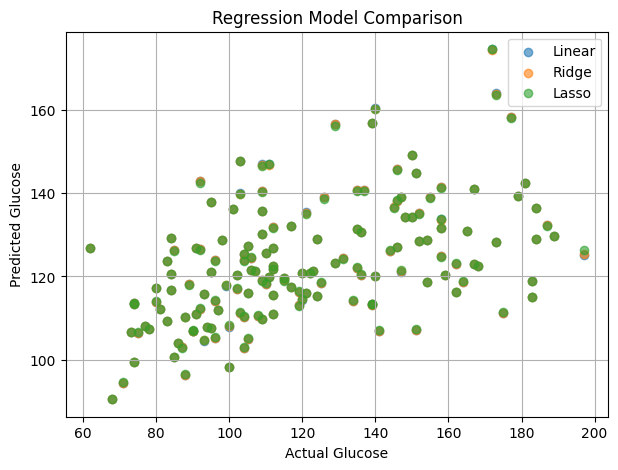

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.6, label='Linear')
plt.scatter(y_test, y_pred_ridge, alpha=0.6, label='Ridge')
plt.scatter(y_test, y_pred_lasso, alpha=0.6, label='Lasso')
plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.legend()
plt.title("Regression Model Comparison")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the range of alpha values to test
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Initialize GridSearchCV for Lasso
lasso_cv = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_mean_squared_error')

# The "Tuning" happens here
lasso_cv.fit(X_train, y_train)

# Results of tuning
print(f"Best Alpha for Lasso: {lasso_cv.best_params_['alpha']}")
best_lasso = lasso_cv.best_estimator_

Best Alpha for Lasso: 0.1
